# Porpoise flight model — `kine` (Minecraft 26.1.2)

Reverse-engineered elytra **autopilot** flight model: a closed loop of the game's real movement
physics, the flight-director state machine, and the autopilot's actuation lag. It's the simulator
the mod's two cruise profiles were optimized against — and it reproduces both from scratch.

**The loop, per tick:**

1. **Flight director** commands a pitch (bang-bang: dive → pull-up → hold → sweep back).
2. **Autopilot** eases the *actual* pitch toward that command (rate-limited — this lag matters).
3. **Physics** (`LivingEntity.updateFallFlyingMovement`) turns pitch into motion.
4. Ground speed feeds back into the director's pull-up trigger.

The two profiles are **CLIMB** (gain altitude) and **HOLD** (cruise at a target altitude). Picking HOLD
turned out to need a *closed-loop* evaluation, not just the raw profile — see the last section.
Everything is verified against the decompiled 26.1.2 client jar.

## 1. The physics

From `net.minecraft.world.entity.LivingEntity.updateFallFlyingMovement` (26.1.2), collapsed to the
vertical plane (constant heading): `vx` = forward horizontal speed, `vy` = vertical, both in
blocks/tick. 1 block = 1 m, 20 ticks/s, so **m/s = blocks/tick × 20**.

With lean angle $\theta$ = pitch (rad), $\text{lift} = \cos^2\theta$, gravity $g = 0.08$:

$$v_y \mathrel{+}= g\,(-1 + 0.75\,\text{lift})$$

$$\text{if } v_y<0:\quad c = -0.1\,\text{lift}\,v_y;\quad v_x \mathrel{+}= c\hat{h}_x,\; v_y \mathrel{+}= c \quad\text{(descent redirect)}$$

$$\text{if } \theta<0:\quad c_3 = 0.04\,h_0\,(-\sin\theta);\quad v_x \mathrel{-}= c_3,\; v_y \mathrel{+}= 3.2\,c_3 \quad\text{(nose-up zoom)}$$

$$v_x \mathrel{+}= 0.1\,(h_0 - v_x) \quad\text{(steering)};\qquad v \mathrel{*}= (0.99,\,0.98) \quad\text{(drag)}$$

The $\times 3.2$ nose-up zoom is the term that makes the porpoise work — it converts horizontal speed
into altitude far more efficiently than it costs, but only while you still *have* horizontal speed.

In [1]:
import math
import matplotlib.pyplot as plt
%matplotlib inline

GRAV   = 0.08    # getEffectiveGravity() for a player, no slow-falling
SMOOTH = 0.15    # Autopilot per-tick pitch ease fraction
CAP    = 7.0     # MAX_DPS (140 deg/s) / 20 = deg per tick

## 2. The closed-loop simulator

`measure()` runs the three layers and returns **steady-state** averages aligned to whole porpoise
cycles. The within-cycle altitude swing is ~100 blocks, so averaging over a fixed tick window aliases
badly — we average *between trigger events* instead. The autopilot lag (`SMOOTH`/`CAP`) is applied
every tick, inside the loop, so any optimization run against this is automatically control-aware.

In [2]:
def measure(DIVE, UP, TRIGGER, TOP_HOLD, SWEEP_RATE,
            ticks=40000, warm=15000, vx0=2.0, vy0=-0.4):
    """Open-loop (single fixed profile); returns (ground_mps, climb_mps, period_s) or None."""
    pitch = DIVE
    vx, vy = vx0, vy0
    x = y = 0.0
    HOLD, TOP, SWEEP = 0, 1, 2
    phase, cmd, topT = HOLD, DIVE, 0
    trig = []
    stall = False
    for t in range(ticks):
        pitch += max(-CAP, min(CAP, (cmd - pitch) * SMOOTH))   # autopilot lag
        pitch = max(-90.0, min(90.0, pitch))
        f = math.radians(pitch); cf = math.cos(f); sf = math.sin(f)
        lift = cf * cf; h0 = vx
        vy += GRAV * (-1.0 + lift * 0.75)
        if vy < 0.0 and cf > 0.0:
            conv = vy * -0.1 * lift; vx += conv; vy += conv
        if f < 0.0 and cf > 0.0:
            conv3 = h0 * (-sf) * 0.04; vx -= conv3; vy += conv3 * 3.2
        if cf > 0.0:
            vx += (h0 - vx) * 0.1
        vx *= 0.99; vy *= 0.98
        x += vx; y += vy
        if vx <= 0.02: stall = True
        hSpeed = vx * 20.0
        if phase == HOLD:
            cmd = DIVE
            if hSpeed >= TRIGGER:
                phase = TOP; topT = 0; cmd = UP
                if t >= warm: trig.append((t, x, y))
        elif phase == TOP:
            cmd = UP; topT += 1
            if topT >= TOP_HOLD: phase = SWEEP
        else:
            cmd += SWEEP_RATE
            if cmd >= DIVE: cmd = DIVE; phase = HOLD
    if stall or len(trig) < 4:
        return None
    t0, x0, y0 = trig[0]; t1, x1, y1 = trig[-1]
    dt = (t1 - t0) / 20.0
    if dt <= 0: return None
    return (x1 - x0) / dt, (y1 - y0) / dt, dt / (len(trig) - 1)

## 3. The two shipped profiles

`(DIVE, UP, TRIGGER, TOP_HOLD, SWEEP_RATE)` — pitch degrees, trigger m/s, hold ticks, sweep deg/tick.
These are `FlightDirector.java`'s `C_*` (climb) and `L_*` (hold). The descending profile is shown for
contrast — it's faster on paper but slower in flight (last section).

In [3]:
PROFILES = {
    "CLIMB":             (40, -62, 44, 11, 0.9),   # max altitude gain
    "HOLD (shipped)":    (38, -66, 52, 13, 1.2),   # gaining; fastest in the CLOSED loop
    "hold (descending)": (38, -73, 52, 12, 1.4),   # raw-fastest near-level; slower once held
    "(old baseline)":    (34, -48, 44, 12, 0.65),  # the hand-tuned profile both replaced
}

for name, p in PROFILES.items():
    g, c, per = measure(*p)
    print(f"{name:18s} DIVE {p[0]:>2} UP {p[1]:>3} TRIG {p[2]:>2} HOLD {p[3]:>2} SWEEP {p[4]:<4} | "
          f"ground {g:5.2f} m/s   climb {c:+.3f} m/s ({c*60:+5.1f} m/min)   cycle {per:.1f}s")

CLIMB              DIVE 40 UP -62 TRIG 44 HOLD 11 SWEEP 0.9  | ground 21.88 m/s   climb +0.924 m/s (+55.4 m/min)   cycle 12.2s
HOLD (shipped)     DIVE 38 UP -66 TRIG 52 HOLD 13 SWEEP 1.2  | ground 29.98 m/s   climb +0.030 m/s ( +1.8 m/min)   cycle 16.2s
hold (descending)  DIVE 38 UP -73 TRIG 52 HOLD 12 SWEEP 1.4  | ground 30.20 m/s   climb -0.030 m/s ( -1.8 m/min)   cycle 15.9s
(old baseline)     DIVE 34 UP -48 TRIG 44 HOLD 12 SWEEP 0.65 | ground 23.32 m/s   climb +0.637 m/s (+38.2 m/min)   cycle 14.2s


## 4. What the porpoise looks like

Trace altitude and ground speed tick-by-tick over a few cycles (open loop, single profile). CLIMB
ratchets upward; HOLD is a near-flat sawtooth at higher speed. The sawtooth *is* the porpoise: dive
to build speed, zoom to trade it back for height.

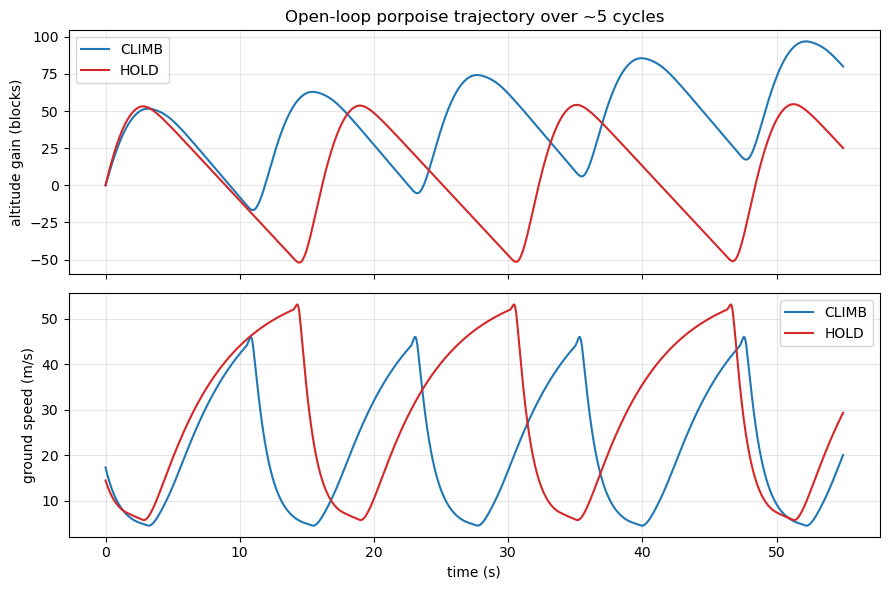

In [4]:
def simulate(DIVE, UP, TRIGGER, TOP_HOLD, SWEEP_RATE, ticks, vx0=2.0, vy0=-0.4):
    """Same loop as measure(), but records the per-tick time series."""
    pitch = DIVE; vx, vy = vx0, vy0; x = y = 0.0
    HOLD, TOP, SWEEP = 0, 1, 2
    phase, cmd, topT = HOLD, DIVE, 0
    T, Y, S = [], [], []
    for t in range(ticks):
        pitch += max(-CAP, min(CAP, (cmd - pitch) * SMOOTH)); pitch = max(-90.0, min(90.0, pitch))
        f = math.radians(pitch); cf = math.cos(f); sf = math.sin(f); lift = cf*cf; h0 = vx
        vy += GRAV * (-1.0 + lift * 0.75)
        if vy < 0.0 and cf > 0.0: conv = vy*-0.1*lift; vx += conv; vy += conv
        if f < 0.0 and cf > 0.0: conv3 = h0*(-sf)*0.04; vx -= conv3; vy += conv3*3.2
        if cf > 0.0: vx += (h0 - vx)*0.1
        vx *= 0.99; vy *= 0.98; x += vx; y += vy
        hSpeed = vx*20.0
        if phase == HOLD:
            cmd = DIVE
            if hSpeed >= TRIGGER: phase = TOP; topT = 0; cmd = UP
        elif phase == TOP:
            cmd = UP; topT += 1
            if topT >= TOP_HOLD: phase = SWEEP
        else:
            cmd += SWEEP_RATE
            if cmd >= DIVE: cmd = DIVE; phase = HOLD
        T.append(t/20.0); Y.append(y); S.append(hSpeed)
    return T, Y, S

WARM = 800
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
for name, key, color in (("CLIMB","CLIMB","tab:blue"), ("HOLD","HOLD (shipped)","tab:red")):
    T, Y, S = simulate(*PROFILES[key], ticks=WARM+1100)
    T = [t - T[WARM] for t in T[WARM:]]; Y = [y - Y[WARM] for y in Y[WARM:]]; S = S[WARM:]
    ax1.plot(T, Y, color=color, label=name); ax2.plot(T, S, color=color, label=name)
ax1.set_ylabel("altitude gain (blocks)"); ax1.legend(); ax1.grid(alpha=0.3)
ax1.set_title("Open-loop porpoise trajectory over ~5 cycles")
ax2.set_ylabel("ground speed (m/s)"); ax2.set_xlabel("time (s)"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Reproduce the open-loop optima

Same `measure()`, two objectives: **CLIMB** maximizes climb rate; **HOLD** maximizes ground speed
subject to ~zero net climb (`|climb| ≤ 0.03`). A coarse grid localizes each optimum, then a local
refine walks onto it. Because the lag lives inside `measure()`, the search over-commands the pull-up
to compensate — that's why the shipped UP angles are steep.

In [5]:
def _grid(Ds, Us, Ts, Hs, Ss, ticks=12000, warm=5000):
    rows = []
    for D in Ds:
        for U in Us:
            for T in Ts:
                for H in Hs:
                    for S in Ss:
                        r = measure(D, U, T, H, S, ticks=ticks, warm=warm)
                        if r is None: continue
                        g, c, per = r
                        if math.isfinite(g) and math.isfinite(c) and 2 < g < 150:
                            rows.append((D, U, T, H, S, g, c))
    return rows

def _refine(seed, score, ok=lambda g, c: True, ticks=24000, warm=10000):
    D, U, T, H, S = seed[:5]; best = None
    for d in (D-2, D, D+2):
        for u in (U-3, U-1, U, U+1, U+3):
            for t in (T-2, T, T+2):
                for h in (H-1, H, H+1):
                    for s in (round(S+e,2) for e in (-0.2,-0.1,0,0.1,0.2)):
                        r = measure(d, u, t, h, s, ticks=ticks, warm=warm)
                        if r is None: continue
                        g, c, per = r
                        if not ok(g, c): continue
                        sc = score(g, c)
                        if best is None or sc > best[0]:
                            best = (sc, (d, u, t, h, s), g, c, per)
    return best

def optimize_climb():
    rows = _grid([34,38,40,42], [-50,-58,-66,-74], [40,44,48], [9,11,13], [0.6,0.9,1.2])
    seed = max((r for r in rows if r[5] >= 15), key=lambda r: r[6])
    return _refine(seed, score=lambda g,c: c, ok=lambda g,c: g >= 15)

def optimize_hold_openloop():
    rows = _grid([36,38,40,42], [-66,-73,-80], [48,52,56], [10,12,14], [1.0,1.4,1.8])
    seed = max((r for r in rows if abs(r[6]) <= 0.05), key=lambda r: r[5])
    return _refine(seed, score=lambda g,c: g, ok=lambda g,c: abs(c) <= 0.03)

sc, p, g, c, per = optimize_climb()
print(f"CLIMB optimum      -> {p}   {g:.2f} m/s   {c*60:+.1f} m/min   (shipped 40 -62 44 11 0.9)")
sc, p, g, c, per = optimize_hold_openloop()
print(f"HOLD open-loop opt -> {p}   {g:.2f} m/s   {c*60:+.1f} m/min   (the *descending* profile)")

CLIMB optimum      -> (40, -57, 44, 12, 0.8)   21.84 m/s   +56.1 m/min   (shipped 40 -62 44 11 0.9)
HOLD open-loop opt -> (38, -70, 52, 11, 1.3)   30.26 m/s   -1.3 m/min   (the *descending* profile)


## 6. Why the shipped HOLD isn't the fastest profile on paper

The open-loop search above picks the raw-fastest near-level profile — and it comes out **descending**
(~&minus;1.8 m/min). But in flight HOLD isn't one fixed profile: an altitude controller regulates the
porpoise trough to a target. When the trough sinks below target it **climb-catches** at ~22 m/s; when
it's above, it **extends the dive** (fast) to descend. So the profile's drift *sign* decides which
correction dominates:

- **Descending** profile → keeps sinking to target → frequent slow climb-catches → average dragged down.
- **Gaining** profile → drifts up → corrected by fast dive-extension, *never* climb-catches → average stays high.

`closedloop()` runs the real controller (`FlightDirector` logic: `decideMode` + dive-extension) and
measures the **long-term average** ground speed.

In [6]:
CLIMB_PROFILE = PROFILES["CLIMB"]

def closedloop(HOLD, target=400, K=0.8, MAXEXT=40, ticks=120000, warm=20000, start=400.0):
    """The shipped altitude-hold controller; returns (avg_mps, climb_fraction, trough_series)."""
    pitch = CLIMB_PROFILE[0]; vx, vy = 2.0, -0.4; y = float(start)
    PH_HOLD, PH_EXT, PH_TOP, PH_SWEEP = 0, 1, 2, 3
    phase, cmd, topT, extLeft = PH_HOLD, CLIMB_PROFILE[0], 0, 0
    climbing, prof, cyc_min = True, CLIMB_PROFILE, 1e9
    dist = tcount = climb_ticks = 0; troughs = []
    for t in range(ticks):
        pitch += max(-CAP, min(CAP, (cmd - pitch) * SMOOTH)); pitch = max(-90, min(90, pitch))
        f = math.radians(pitch); cf = math.cos(f); sf = math.sin(f); lift = cf*cf; h0 = vx
        vy += GRAV * (-1 + lift*0.75)
        if vy < 0 and cf > 0: c = vy*-0.1*lift; vx += c; vy += c
        if f < 0 and cf > 0: c3 = h0*(-sf)*0.04; vx -= c3; vy += c3*3.2
        if cf > 0: vx += (h0 - vx)*0.1
        vx *= 0.99; vy *= 0.98; y += vy
        if y < cyc_min: cyc_min = y
        if t >= warm:
            dist += vx; tcount += 1
            if climbing: climb_ticks += 1
        hS = vx*20; D, U, TR, HO, SW = prof
        if phase == PH_HOLD:
            cmd = D
            if hS >= TR:                                  # trough: decide mode for next cycle
                err = cyc_min - target; climbing = err < 0
                prof = CLIMB_PROFILE if climbing else HOLD
                extLeft = 0 if climbing else min(MAXEXT, int(round(K*max(0.0, err))))
                if t >= warm: troughs.append((t/20.0, cyc_min))
                cyc_min = 1e9
                if extLeft > 0: phase = PH_EXT
                else: phase = PH_TOP; topT = 0; cmd = prof[1]
        elif phase == PH_EXT:
            cmd = prof[0]; extLeft -= 1
            if extLeft <= 0: phase = PH_TOP; topT = 0; cmd = prof[1]
        elif phase == PH_TOP:
            cmd = prof[1]; topT += 1
            if topT >= prof[3]: phase = PH_SWEEP
        else:
            cmd += prof[4]
            if cmd >= prof[0]: cmd = prof[0]; phase = PH_HOLD
    return (dist/tcount)*20.0, climb_ticks/tcount, troughs

print("Long-term AVERAGE ground speed holding target = 400:\n")
for name, key in (("descending", "hold (descending)"), ("gaining (shipped)", "HOLD (shipped)")):
    avg, cf, _ = closedloop(PROFILES[key])
    raw = measure(*PROFILES[key])[0]
    print(f"  {name:18s} raw {raw:5.2f} m/s  ->  closed-loop avg {avg:5.2f} m/s   "
          f"(time climb-catching: {cf*100:2.0f}%)")

Long-term AVERAGE ground speed holding target = 400:

  descending         raw 30.20 m/s  ->  closed-loop avg 29.80 m/s   (time climb-catching: 10%)
  gaining (shipped)  raw 29.98 m/s  ->  closed-loop avg 30.13 m/s   (time climb-catching:  0%)


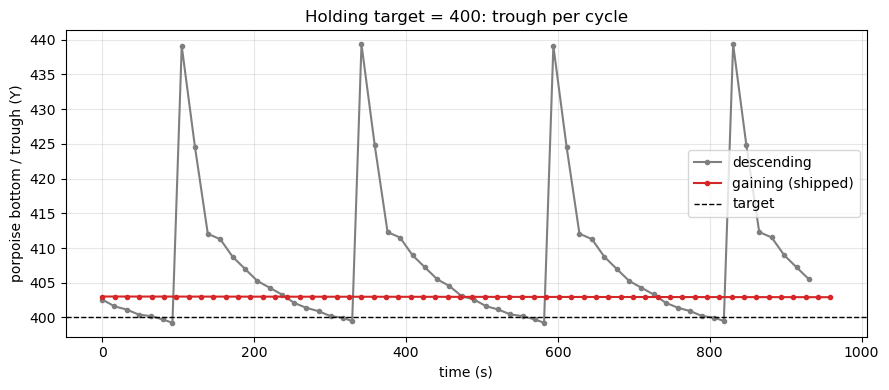

In [7]:
# The trough is the controlled variable -- plot it per cycle against the target.
fig, ax = plt.subplots(figsize=(9, 4))
for name, key, color in (("descending","hold (descending)","tab:gray"),
                         ("gaining (shipped)","HOLD (shipped)","tab:red")):
    _, _, tr = closedloop(PROFILES[key], ticks=60000, warm=8000)
    tr = [(t - tr[0][0], y) for t, y in tr][:60]
    ax.plot([t for t,_ in tr], [y for _,y in tr], "o-", ms=3, color=color, label=name)
ax.axhline(400, color="k", lw=1, ls="--", label="target")
ax.set_xlabel("time (s)"); ax.set_ylabel("porpoise bottom / trough (Y)")
ax.set_title("Holding target = 400: trough per cycle"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

The descending profile's troughs saw-tooth across the target (dip under → climb-catch back over),
spending ~10% of the time slow; the gaining profile's troughs sit **at or above** target and are
trimmed down by dive-extension, so it never climb-catches and its average comes out **higher** despite
the lower raw speed. That's why `L_*` ships as the gaining profile and `L_SPEED` is the closed-loop
average (~30.1), not the raw figure.

One more verified, counterintuitive corollary: making the autopilot respond **faster** (larger
`SMOOTH`/`CAP`) *lowers* both open-loop optima — the lag dwells the nose on the productive mid-range
angles while you're still fast, so it's load-bearing, not a tax.